# Generation of Synthetic Dataset


## 1. imports


In [5]:

import pandas as pd
import matplotlib.pyplot as plt

## 2. Dataset

### 2.1 Real Apple TS

Lade Apple-Kursdaten aus lokalem Cache: ../data/stock_prices/AAPL_2012-01-01_2026-06-12.csv

                Apple (AAPL) Tageskurse 2012–2026                
          (split-bereinigt, via Yahoo Finance, in USD)           
Datum            Kurs (USD)   Veränd. (%)    Veränd. (USD)
-----------------------------------------------------------------
2012-01-03     $     12.31         —               —
2012-01-04     $     12.38     +  0.54%       +$   0.07
2012-01-05     $     12.51     +  1.11%       +$   0.14
2012-01-06     $     12.64     +  1.05%       +$   0.13
2012-01-09     $     12.62       -0.16%       -$   0.02
2012-01-10     $     12.67     +  0.36%       +$   0.05
2012-01-11     $     12.65       -0.16%       -$   0.02
2012-01-12     $     12.61       -0.27%       -$   0.03
2012-01-13     $     12.57       -0.37%       -$   0.05
2012-01-17     $     12.71     +  1.16%       +$   0.15
2012-01-18     $     12.85     +  1.04%       +$   0.13
2012-01-19     $     12.80       -0.3

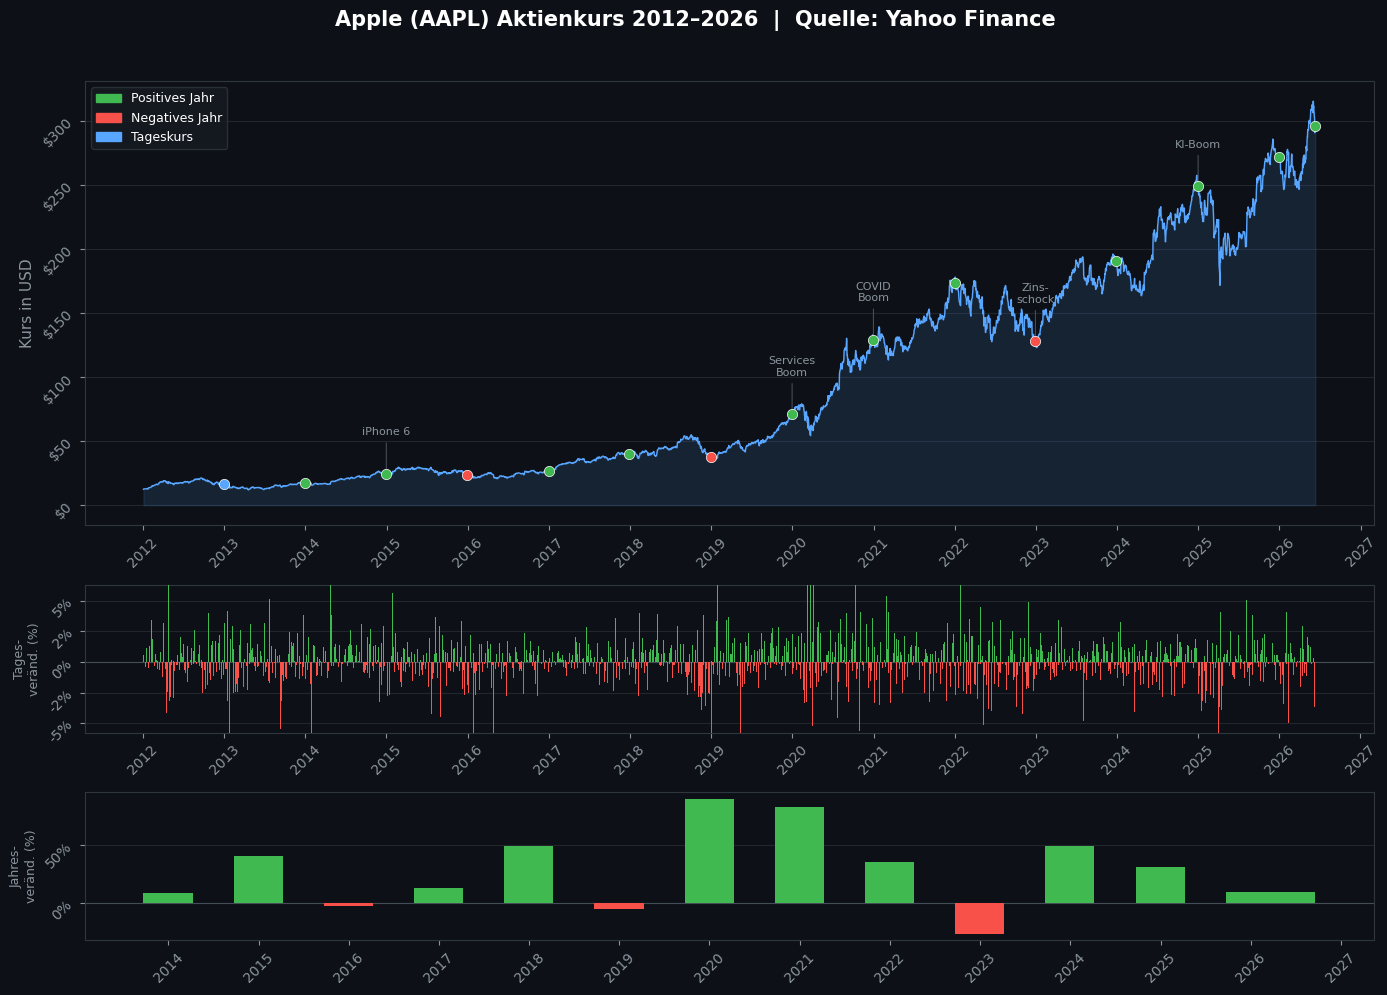

In [9]:
import os
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

# ── Konfiguration ─────────────────────────────────────────────────
TICKER = "AAPL"
START = "2012-01-01"
END = "2026-06-12"
DATA_DIR = "../data/stock_prices"
CACHE_FILE = os.path.join(DATA_DIR, f"{TICKER}_{START}_{END}.csv")

# ── Daten laden (aus Cache oder von Yahoo Finance) ─────────────────
os.makedirs(DATA_DIR, exist_ok=True)

if os.path.exists(CACHE_FILE):
    print(f"Lade Apple-Kursdaten aus lokalem Cache: {CACHE_FILE}")
    df = pd.read_csv(CACHE_FILE, index_col=0, parse_dates=True)
else:
    print("Lade Apple-Kursdaten von Yahoo Finance...")
    df = yf.download(TICKER, start=START, end=END, progress=False)
    df = df[["Close"]].copy()
    df.columns = ["Kurs"]
    df.index = df.index.tz_localize(None)  # Zeitzone entfernen
    df.to_csv(CACHE_FILE)
    print(f"Daten gespeichert unter: {CACHE_FILE}")

# Jahresschlusskurse
jahres = df.resample("YE").last()
jahres.index = jahres.index.year

# ── Tagesweise Konsolenausgabe ───────────────────────────────────
print("\n" + "=" * 65)
print(f"{'Apple (AAPL) Tageskurse 2012–2026':^65}")
print(f"{'(split-bereinigt, via Yahoo Finance, in USD)':^65}")
print("=" * 65)
print(f"{'Datum':<14} {'Kurs (USD)':>12}   {'Veränd. (%)':<14} {'Veränd. (USD)'}")
print("-" * 65)

prev = None
for datum, row in df.iterrows():
    kurs = row["Kurs"]
    if prev is None:
        pct_str, abs_str = "      —", "       —"
    else:
        pct = (kurs - prev) / prev * 100
        absd = kurs - prev
        pct_str = f"  +{pct:6.2f}%" if pct >= 0 else f"  {pct:7.2f}%"
        abs_str = f"  +${absd:7.2f}" if absd >= 0 else f"  -${abs(absd):7.2f}"
    print(f"{str(datum.date()):<14} ${kurs:>10.2f}   {pct_str:<14} {abs_str}")
    prev = kurs

print("-" * 65)
gesamt = (df["Kurs"].iloc[-1] - df["Kurs"].iloc[0]) / df["Kurs"].iloc[0] * 100
print(f"{'Gesamtrendite:':<35} +{gesamt:.0f}%")
print(f"{'Aus $1.000 wurden:':<35} ${1000 * df['Kurs'].iloc[-1] / df['Kurs'].iloc[0]:,.0f}")
print("=" * 65)

# ── Jahresübersicht ──────────────────────────────────────────────
kurse_list = jahres["Kurs"].tolist()
jahre_list = jahres.index.tolist()

print("\n" + "=" * 55)
print(f"{'Jahresübersicht':^55}")
print("=" * 55)
print(f"{'Jahr':<8} {'Kurs (USD)':>12}   {'Veränd. (%)':<14} {'Trend'}")
print("-" * 55)
for i, (jahr, kurs) in enumerate(zip(jahre_list, kurse_list)):
    if i == 0:
        pct_str, trend = "      —", ""
    else:
        pct = (kurs - kurse_list[i - 1]) / kurse_list[i - 1] * 100
        pct_str = f"  +{pct:6.2f}%" if pct >= 0 else f"  {pct:7.2f}%"
        trend = "▲" * min(int(abs(pct) / 15) + 1, 5) if pct >= 0 else "▼"
    hinweis = " ← aktuell" if i == len(jahre_list) - 1 else ""
    print(f"{jahr:<8} ${kurs:>10.2f}   {pct_str:<14} {trend}{hinweis}")
print("=" * 55)

# ── Grafik ───────────────────────────────────────────────────────
fig, axes = plt.subplots(
    3, 1, figsize=(14, 10),
    gridspec_kw={"height_ratios": [3, 1, 1]},
    facecolor="#0d1117"
)
ax1, ax2, ax3 = axes
fig.suptitle(
    "Apple (AAPL) Aktienkurs 2012–2026  |  Quelle: Yahoo Finance",
    color="white", fontsize=15, fontweight="bold", y=0.99
)

# — ax1: Tageskurs-Linie —
ax1.set_facecolor("#0d1117")
ax1.plot(df.index, df["Kurs"], color="#58a6ff", linewidth=1.0, zorder=3)
ax1.fill_between(df.index, df["Kurs"], alpha=0.12, color="#58a6ff", zorder=2)

# Jahrespunkte einfärben
for i, (jahr, kurs) in enumerate(zip(jahre_list, kurse_list)):
    if i == 0:
        farbe = "#58a6ff"
    else:
        farbe = "#3fb950" if kurs >= kurse_list[i - 1] else "#f85149"
    datum = df[df.index.year == jahr].index[-1]
    ax1.scatter(datum, kurs, color=farbe, s=55, zorder=4,
                edgecolors="white", linewidths=0.5)

# Ereignis-Annotationen
ereignisse = {
    2014: "iPhone 6",
    2019: "Services\nBoom",
    2020: "COVID\nBoom",
    2022: "Zins-\nschock",
    2024: "KI-Boom",
}
for jahr, label in ereignisse.items():
    if jahr in jahres.index:
        kurs = jahres.loc[jahr, "Kurs"]
        datum = df[df.index.year == jahr].index[-1]
        ax1.annotate(
            label, xy=(datum, kurs), xytext=(datum, kurs + 30),
            fontsize=8, color="#8b949e", ha="center",
            arrowprops=dict(arrowstyle="-", color="#444c56", lw=0.8),
        )

ax1.set_ylabel("Kurs in USD", color="#8b949e", fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0f"))
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.tick_params(colors="#8b949e", rotation=45)
for spine in ax1.spines.values():
    spine.set_edgecolor("#30363d")
ax1.grid(axis="y", color="#21262d", linewidth=0.8)
ax1.set_axisbelow(True)

# — ax2: tägliche Veränderung in % —
ax2.set_facecolor("#0d1117")
tages_pct = df["Kurs"].pct_change() * 100
farben_tag = ["#3fb950" if v >= 0 else "#f85149" for v in tages_pct]
ax2.bar(df.index, tages_pct, color=farben_tag, width=1.5, zorder=3)
ax2.axhline(0, color="#444c56", linewidth=0.8)
ax2.set_ylabel("Tages-\nveränd. (%)", color="#8b949e", fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax2.set_ylim(tages_pct.quantile(0.005), tages_pct.quantile(0.995))
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.tick_params(colors="#8b949e", rotation=45)
for spine in ax2.spines.values():
    spine.set_edgecolor("#30363d")
ax2.grid(axis="y", color="#21262d", linewidth=0.8)
ax2.set_axisbelow(True)

# — ax3: jährliche Veränderung —
ax3.set_facecolor("#0d1117")
farben_j, werte_j, pos_j = [], [], []
for i in range(1, len(jahre_list)):
    pct = (kurse_list[i] - kurse_list[i - 1]) / kurse_list[i - 1] * 100
    datum = df[df.index.year == jahre_list[i]].index[-1]
    pos_j.append(datum)
    werte_j.append(pct)
    farben_j.append("#3fb950" if pct >= 0 else "#f85149")

ax3.bar(pos_j, werte_j, color=farben_j, width=200, zorder=3)
ax3.axhline(0, color="#444c56", linewidth=0.8)
ax3.set_ylabel("Jahres-\nveränd. (%)", color="#8b949e", fontsize=9)
ax3.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax3.xaxis.set_major_locator(mdates.YearLocator())
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax3.tick_params(colors="#8b949e", rotation=45)
for spine in ax3.spines.values():
    spine.set_edgecolor("#30363d")
ax3.grid(axis="y", color="#21262d", linewidth=0.8)
ax3.set_axisbelow(True)

# Legende
from matplotlib.patches import Patch
ax1.legend(
    handles=[
        Patch(color="#3fb950", label="Positives Jahr"),
        Patch(color="#f85149", label="Negatives Jahr"),
        Patch(color="#58a6ff", label="Tageskurs"),
    ],
    loc="upper left", facecolor="#161b22",
    edgecolor="#30363d", labelcolor="white", fontsize=9
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("apple_kurs_yfinance.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
print("\nGrafik gespeichert: apple_kurs_yfinance.png")
plt.show()

### 2.2 Real Microsoft TS

Lade Microsoft-Kursdaten von Yahoo Finance...
Daten gespeichert unter: ../data/stock_prices/MSFT_2012-01-01_2026-06-12.csv

              Microsoft (MSFT) Tageskurse 2012–2026              
          (split-bereinigt, via Yahoo Finance, in USD)           
Datum            Kurs (USD)   Veränd. (%)    Veränd. (USD)
-----------------------------------------------------------------
2012-01-03     $     20.87         —               —
2012-01-04     $     21.36     +  2.35%       +$   0.49
2012-01-05     $     21.58     +  1.02%       +$   0.22
2012-01-06     $     21.92     +  1.55%       +$   0.34
2012-01-09     $     21.63       -1.32%       -$   0.29
2012-01-10     $     21.71     +  0.36%       +$   0.08
2012-01-11     $     21.61       -0.43%       -$   0.09
2012-01-12     $     21.83     +  1.01%       +$   0.22
2012-01-13     $     22.03     +  0.89%       +$   0.19
2012-01-17     $     22.03     +  0.04%       +$   0.01
2012-01-18     $     22.01       -0.11%       -$   0.02
2012-0

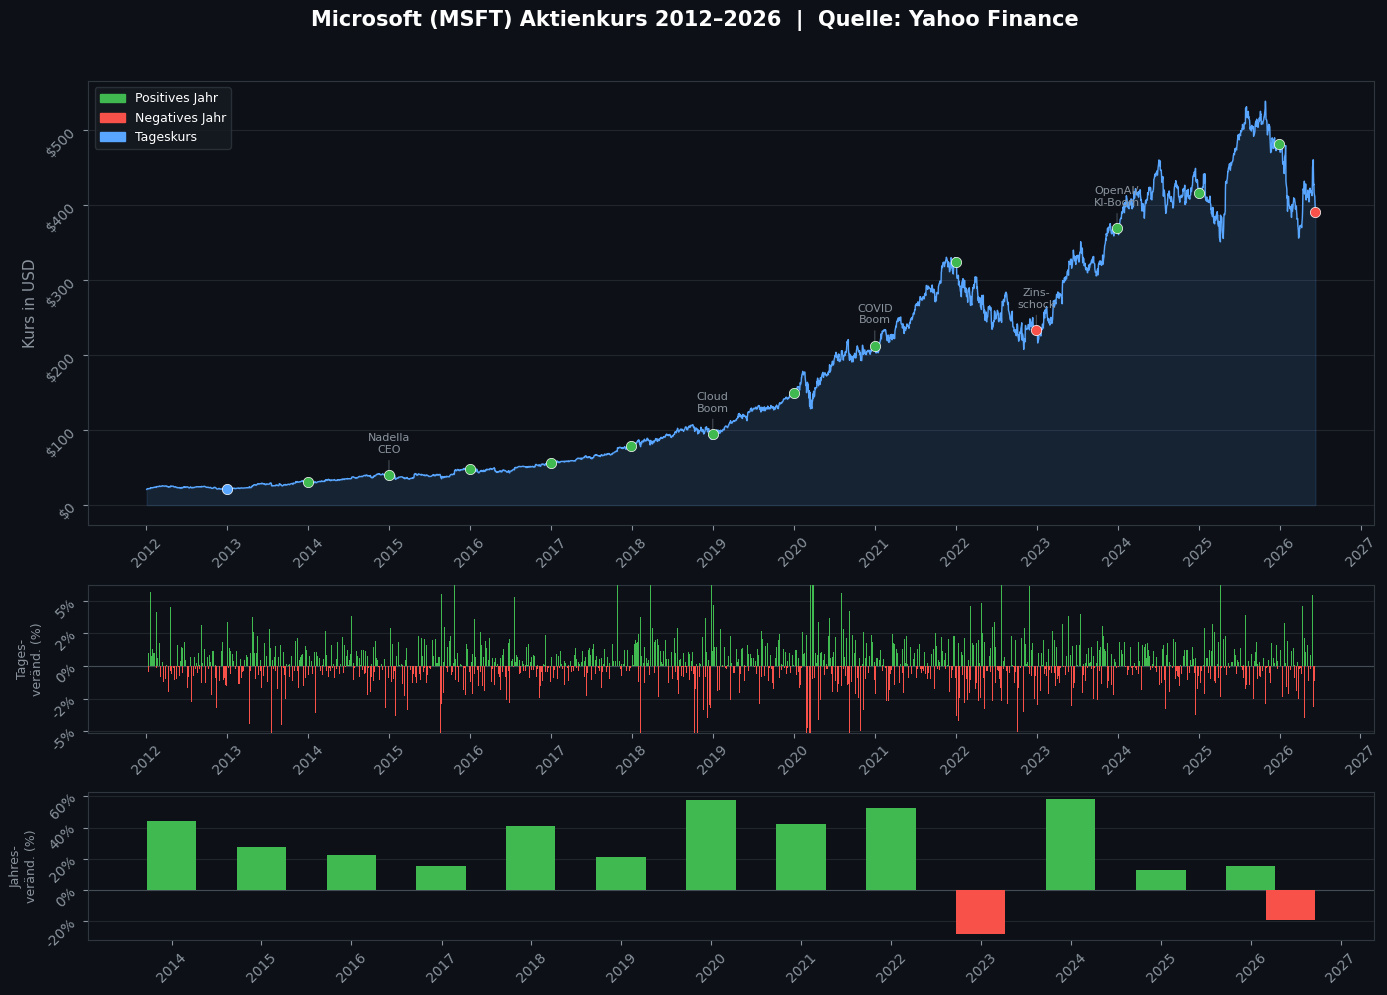

In [10]:
import os
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

# ── Konfiguration ─────────────────────────────────────────────────
TICKER = "MSFT"
START = "2012-01-01"
END = "2026-06-12"
DATA_DIR = "../data/stock_prices"
CACHE_FILE = os.path.join(DATA_DIR, f"{TICKER}_{START}_{END}.csv")

# ── Daten laden (aus Cache oder von Yahoo Finance) ─────────────────
os.makedirs(DATA_DIR, exist_ok=True)

if os.path.exists(CACHE_FILE):
    print(f"Lade Microsoft-Kursdaten aus lokalem Cache: {CACHE_FILE}")
    df = pd.read_csv(CACHE_FILE, index_col=0, parse_dates=True)
else:
    print("Lade Microsoft-Kursdaten von Yahoo Finance...")
    df = yf.download(TICKER, start=START, end=END, progress=False)
    df = df[["Close"]].copy()
    df.columns = ["Kurs"]
    df.index = df.index.tz_localize(None)  # Zeitzone entfernen
    df.to_csv(CACHE_FILE)
    print(f"Daten gespeichert unter: {CACHE_FILE}")

# Jahresschlusskurse
jahres = df.resample("YE").last()
jahres.index = jahres.index.year

# ── Tagesweise Konsolenausgabe ───────────────────────────────────
print("\n" + "=" * 65)
print(f"{'Microsoft (MSFT) Tageskurse 2012–2026':^65}")
print(f"{'(split-bereinigt, via Yahoo Finance, in USD)':^65}")
print("=" * 65)
print(f"{'Datum':<14} {'Kurs (USD)':>12}   {'Veränd. (%)':<14} {'Veränd. (USD)'}")
print("-" * 65)

prev = None
for datum, row in df.iterrows():
    kurs = row["Kurs"]
    if prev is None:
        pct_str, abs_str = "      —", "       —"
    else:
        pct = (kurs - prev) / prev * 100
        absd = kurs - prev
        pct_str = f"  +{pct:6.2f}%" if pct >= 0 else f"  {pct:7.2f}%"
        abs_str = f"  +${absd:7.2f}" if absd >= 0 else f"  -${abs(absd):7.2f}"
    print(f"{str(datum.date()):<14} ${kurs:>10.2f}   {pct_str:<14} {abs_str}")
    prev = kurs

print("-" * 65)
gesamt = (df["Kurs"].iloc[-1] - df["Kurs"].iloc[0]) / df["Kurs"].iloc[0] * 100
print(f"{'Gesamtrendite:':<35} +{gesamt:.0f}%")
print(f"{'Aus $1.000 wurden:':<35} ${1000 * df['Kurs'].iloc[-1] / df['Kurs'].iloc[0]:,.0f}")
print("=" * 65)

# ── Jahresübersicht ──────────────────────────────────────────────
kurse_list = jahres["Kurs"].tolist()
jahre_list = jahres.index.tolist()

print("\n" + "=" * 55)
print(f"{'Jahresübersicht':^55}")
print("=" * 55)
print(f"{'Jahr':<8} {'Kurs (USD)':>12}   {'Veränd. (%)':<14} {'Trend'}")
print("-" * 55)
for i, (jahr, kurs) in enumerate(zip(jahre_list, kurse_list)):
    if i == 0:
        pct_str, trend = "      —", ""
    else:
        pct = (kurs - kurse_list[i - 1]) / kurse_list[i - 1] * 100
        pct_str = f"  +{pct:6.2f}%" if pct >= 0 else f"  {pct:7.2f}%"
        trend = "▲" * min(int(abs(pct) / 15) + 1, 5) if pct >= 0 else "▼"
    hinweis = " ← aktuell" if i == len(jahre_list) - 1 else ""
    print(f"{jahr:<8} ${kurs:>10.2f}   {pct_str:<14} {trend}{hinweis}")
print("=" * 55)

# ── Grafik ───────────────────────────────────────────────────────
fig, axes = plt.subplots(
    3, 1, figsize=(14, 10),
    gridspec_kw={"height_ratios": [3, 1, 1]},
    facecolor="#0d1117"
)
ax1, ax2, ax3 = axes
fig.suptitle(
    "Microsoft (MSFT) Aktienkurs 2012–2026  |  Quelle: Yahoo Finance",
    color="white", fontsize=15, fontweight="bold", y=0.99
)

# — ax1: Tageskurs-Linie —
ax1.set_facecolor("#0d1117")
ax1.plot(df.index, df["Kurs"], color="#58a6ff", linewidth=1.0, zorder=3)
ax1.fill_between(df.index, df["Kurs"], alpha=0.12, color="#58a6ff", zorder=2)

# Jahrespunkte einfärben
for i, (jahr, kurs) in enumerate(zip(jahre_list, kurse_list)):
    if i == 0:
        farbe = "#58a6ff"
    else:
        farbe = "#3fb950" if kurs >= kurse_list[i - 1] else "#f85149"
    datum = df[df.index.year == jahr].index[-1]
    ax1.scatter(datum, kurs, color=farbe, s=55, zorder=4,
                edgecolors="white", linewidths=0.5)

# Ereignis-Annotationen
ereignisse = {
    2014: "Nadella\nCEO",
    2018: "Cloud\nBoom",
    2020: "COVID\nBoom",
    2022: "Zins-\nschock",
    2023: "OpenAI/\nKI-Boom",
}
for jahr, label in ereignisse.items():
    if jahr in jahres.index:
        kurs = jahres.loc[jahr, "Kurs"]
        datum = df[df.index.year == jahr].index[-1]
        ax1.annotate(
            label, xy=(datum, kurs), xytext=(datum, kurs + 30),
            fontsize=8, color="#8b949e", ha="center",
            arrowprops=dict(arrowstyle="-", color="#444c56", lw=0.8),
        )

ax1.set_ylabel("Kurs in USD", color="#8b949e", fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0f"))
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.tick_params(colors="#8b949e", rotation=45)
for spine in ax1.spines.values():
    spine.set_edgecolor("#30363d")
ax1.grid(axis="y", color="#21262d", linewidth=0.8)
ax1.set_axisbelow(True)

# — ax2: tägliche Veränderung in % —
ax2.set_facecolor("#0d1117")
tages_pct = df["Kurs"].pct_change() * 100
farben_tag = ["#3fb950" if v >= 0 else "#f85149" for v in tages_pct]
ax2.bar(df.index, tages_pct, color=farben_tag, width=1.5, zorder=3)
ax2.axhline(0, color="#444c56", linewidth=0.8)
ax2.set_ylabel("Tages-\nveränd. (%)", color="#8b949e", fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax2.set_ylim(tages_pct.quantile(0.005), tages_pct.quantile(0.995))
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.tick_params(colors="#8b949e", rotation=45)
for spine in ax2.spines.values():
    spine.set_edgecolor("#30363d")
ax2.grid(axis="y", color="#21262d", linewidth=0.8)
ax2.set_axisbelow(True)

# — ax3: jährliche Veränderung —
ax3.set_facecolor("#0d1117")
farben_j, werte_j, pos_j = [], [], []
for i in range(1, len(jahre_list)):
    pct = (kurse_list[i] - kurse_list[i - 1]) / kurse_list[i - 1] * 100
    datum = df[df.index.year == jahre_list[i]].index[-1]
    pos_j.append(datum)
    werte_j.append(pct)
    farben_j.append("#3fb950" if pct >= 0 else "#f85149")

ax3.bar(pos_j, werte_j, color=farben_j, width=200, zorder=3)
ax3.axhline(0, color="#444c56", linewidth=0.8)
ax3.set_ylabel("Jahres-\nveränd. (%)", color="#8b949e", fontsize=9)
ax3.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax3.xaxis.set_major_locator(mdates.YearLocator())
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax3.tick_params(colors="#8b949e", rotation=45)
for spine in ax3.spines.values():
    spine.set_edgecolor("#30363d")
ax3.grid(axis="y", color="#21262d", linewidth=0.8)
ax3.set_axisbelow(True)

# Legende
from matplotlib.patches import Patch
ax1.legend(
    handles=[
        Patch(color="#3fb950", label="Positives Jahr"),
        Patch(color="#f85149", label="Negatives Jahr"),
        Patch(color="#58a6ff", label="Tageskurs"),
    ],
    loc="upper left", facecolor="#161b22",
    edgecolor="#30363d", labelcolor="white", fontsize=9
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("msft_kurs_yfinance.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
print("\nGrafik gespeichert: msft_kurs_yfinance.png")
plt.show()

### 2.3 Real Silver and Gold Prices

Lade Gold (GC=F) von Yahoo Finance...
Daten gespeichert unter: ../data/stock_prices/GC_F_1990-01-01_2025-12-31.csv
  Gold: 2000-08-30 bis 2025-12-30, 6357 Beobachtungen
Lade Silver (SI=F) von Yahoo Finance...
Daten gespeichert unter: ../data/stock_prices/SI_F_1990-01-01_2025-12-31.csv
  Silver: 2000-08-30 bis 2025-12-30, 6359 Beobachtungen

Gemeinsame Datenpunkte: 6356
Gesamtkorrelation (Preise, levels): 0.895
Korrelation der täglichen Returns:   0.775

Grafik gespeichert: gold_silver_1990_2025.png


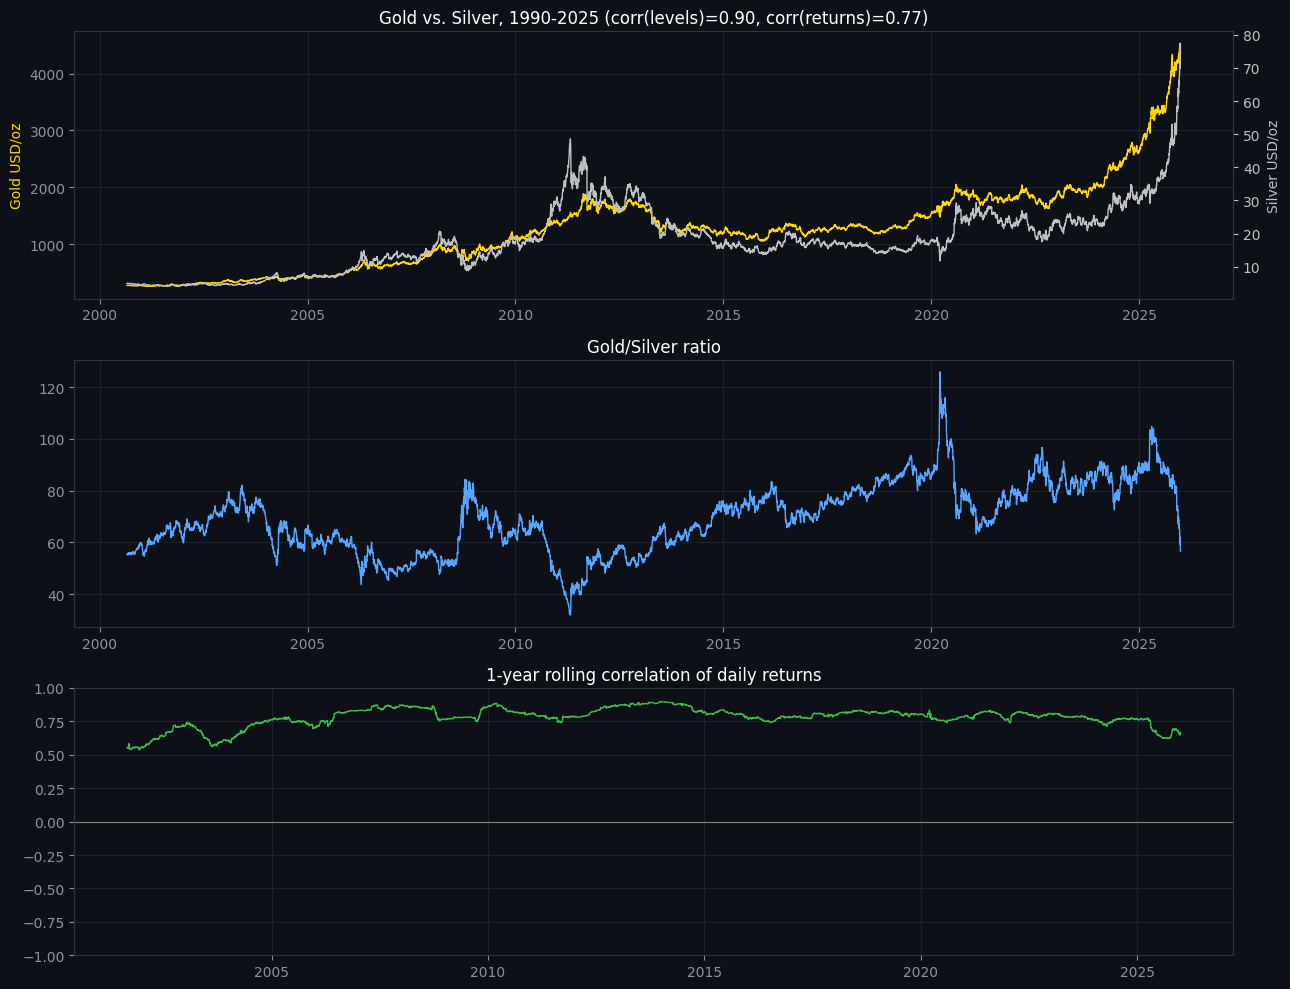

Daten gespeichert: gold_silver_1990_2025.csv


In [11]:
"""
Fetch gold and silver prices from Yahoo Finance (1990-2025), cache locally,
and plot both series together with their rolling correlation.

Tickers:
    GC=F  -> COMEX Gold futures (continuous contract)
    SI=F  -> COMEX Silver futures (continuous contract)

Run with:
    pip install yfinance pandas matplotlib --break-system-packages
    python gold_silver_yfinance.py
"""

import os
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Configuration ───────────────────────────────────────────────
START = "1990-01-01"
END = "2025-12-31"
DATA_DIR = "../data/stock_prices"
TICKERS = {"GC=F": "Gold", "SI=F": "Silver"}

os.makedirs(DATA_DIR, exist_ok=True)

data = {}
for ticker, name in TICKERS.items():
    cache_file = os.path.join(DATA_DIR, f"{ticker.replace('=', '_')}_{START}_{END}.csv")
    if os.path.exists(cache_file):
        print(f"Lade {name} ({ticker}) aus lokalem Cache: {cache_file}")
        df = pd.read_csv(cache_file, index_col=0, parse_dates=True)
    else:
        print(f"Lade {name} ({ticker}) von Yahoo Finance...")
        df = yf.download(ticker, start=START, end=END, progress=False)
        df = df[["Close"]].copy()
        df.columns = [name]
        df.index = df.index.tz_localize(None)
        df.to_csv(cache_file)
        print(f"Daten gespeichert unter: {cache_file}")
        df.columns = [name]
    data[name] = df[df.columns[0]]
    print(f"  {name}: {df.index.min().date()} bis {df.index.max().date()}, "
          f"{len(df)} Beobachtungen")

# ── Combine into one DataFrame (inner join on common dates) ───────
combined = pd.concat(data, axis=1).dropna()
print(f"\nGemeinsame Datenpunkte: {len(combined)}")

# ── Correlation ─────────────────────────────────────────────────
corr_full = combined["Gold"].corr(combined["Silver"])
print(f"Gesamtkorrelation (Preise, levels): {corr_full:.3f}")

returns = combined.pct_change().dropna()
corr_returns = returns["Gold"].corr(returns["Silver"])
print(f"Korrelation der täglichen Returns:   {corr_returns:.3f}")

rolling_corr = returns["Gold"].rolling(252).corr(returns["Silver"])

# ── Gold-silver ratio ──────────────────────────────────────────────
ratio = combined["Gold"] / combined["Silver"]

# ── Plot ────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 10), facecolor="#0d1117")
ax1, ax2, ax3 = axes

# Panel 1: both prices (different scales -> twin axis)
ax1.set_facecolor("#0d1117")
ax1.plot(combined.index, combined["Gold"], color="#FFD700", lw=1.0, label="Gold (USD/oz)")
ax1.set_ylabel("Gold USD/oz", color="#FFD700")
ax1b = ax1.twinx()
ax1b.plot(combined.index, combined["Silver"], color="#C0C0C0", lw=1.0, label="Silver (USD/oz)")
ax1b.set_ylabel("Silver USD/oz", color="#C0C0C0")
ax1b.tick_params(colors="#C0C0C0")
ax1.set_title(f"Gold vs. Silver, {START[:4]}-{END[:4]} "
               f"(corr(levels)={corr_full:.2f}, corr(returns)={corr_returns:.2f})",
               color="white", fontsize=12)

# Panel 2: gold-silver ratio
ax2.set_facecolor("#0d1117")
ax2.plot(combined.index, ratio, color="#58a6ff", lw=1.0)
ax2.set_title("Gold/Silver ratio", color="white", fontsize=12)

# Panel 3: rolling 1-year correlation of returns
ax3.set_facecolor("#0d1117")
ax3.plot(rolling_corr.index, rolling_corr, color="#3fb950", lw=1.0)
ax3.axhline(0, color="#888780", lw=0.8)
ax3.set_title("1-year rolling correlation of daily returns", color="white", fontsize=12)
ax3.set_ylim(-1, 1)

for ax in (ax1, ax2, ax3):
    ax.tick_params(colors="#8b949e")
    for spine in ax.spines.values():
        spine.set_edgecolor("#30363d")
    ax.grid(color="#21262d", linewidth=0.6)
    ax.set_axisbelow(True)
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
for spine in ax1b.spines.values():
    spine.set_edgecolor("#30363d")

plt.tight_layout()
plt.savefig("gold_silver_1990_2025.png", dpi=150,
            bbox_inches="tight", facecolor="#0d1117")
print("\nGrafik gespeichert: gold_silver_1990_2025.png")
plt.show()

combined.to_csv("gold_silver_1990_2025.csv")
print("Daten gespeichert: gold_silver_1990_2025.csv")

### 3. Sampled Silver and Gold

In [13]:
"""
Full synthetic Gold & Silver price simulation, 1970-2025.

Combines THREE building blocks from earlier:
  1. Exponential drift trends (each metal has its own growth rate r_i)
  2. A random-walk (GBM-style) noise component with a TARGET CORRELATION
     between gold's and silver's daily returns (via Cholesky decomposition)
  3. n_struc SHARED structural breaks (macro shocks affecting both metals
     at the same time), each with its own recovery horizon h_j. Silver
     reacts more strongly than gold to each shock ("high-beta" behaviour),
     consistent with the empirical gold-silver literature.

Model (for each series i = gold, silver):
    log(P_i,t) = log(P_i,0) + r_i * t + dev_i,t + cumsum(eps_i,t)

    dev_i,t = sum over breaks j of:
        delta_i,j * max(0, 1 - (t - t_struc_j) / h_j)   for t in [t_struc_j, t_struc_j+h_j]

    eps_gold,t, eps_silver,t  ~ bivariate normal with corr = rho_target

    delta_silver,j = beta_silver * delta_gold,j + small independent noise
        (silver's break reaction is `beta_silver` times gold's, on average)

EVERYTHING is driven by a single `seed` -> fully reproducible.

Run with:
    pip install numpy pandas matplotlib --break-system-packages
    python simulate_gold_silver_full.py
"""

import os
import numpy as np
import pandas as pd

# ── Fixed configuration ────────────────────────────────────────────
START = "1970-01-01"
END = "2025-12-31"

# Exponential drift trends (calibrated to roughly match real 1970->2025 levels)
P0_GOLD, R_GOLD = 35.0, 0.0817      # ~$35/oz 1970 -> ~$3400/oz 2025, 8.17%/yr
P0_SILVER, R_SILVER = 1.6, 0.0551   # ~$1.6/oz 1970 -> ~$35/oz 2025, 5.51%/yr

SIGMA_GOLD, SIGMA_SILVER = 0.010, 0.018   # daily noise std dev (silver more volatile)
RHO_TARGET = 0.77                          # target correlation of daily returns

# Structural breaks
H_MIN, H_MAX = 30, 250            # recovery horizon h_j (trading days)
MAG_MIN, MAG_MAX = 0.08, 0.35     # |gold break magnitude| range (log-points)
BETA_SILVER = 1.4                 # silver reacts ~1.4x as strongly as gold ("high beta")
MAG_NOISE = 0.05                  # extra independent noise on silver's magnitude

DATES = pd.bdate_range(START, END)
N = len(DATES)
T = np.arange(N) / 252.0

BASELINE_GOLD = np.log(P0_GOLD) + R_GOLD * T
BASELINE_SILVER = np.log(P0_SILVER) + R_SILVER * T


def simulate(seed: int) -> dict:
    rng = np.random.default_rng(seed)

    # ── Structural breaks: shared dates, per-series magnitudes ──────
    n_struc = int(rng.integers(11, 18))  # ~2-3 per decade over 56 years

    h_js = rng.integers(H_MIN, H_MAX + 1, size=n_struc)

    margin = H_MAX
    usable_range = N - 2 * margin
    spacing = usable_range / n_struc
    t_struc = []
    for j in range(n_struc):
        center = margin + (j + 0.5) * spacing
        jitter = rng.uniform(-spacing * 0.3, spacing * 0.3)
        bp = int(np.clip(center + jitter, margin, N - margin))
        t_struc.append(bp)

    order = np.argsort(t_struc)
    t_struc = np.array(t_struc)[order]
    h_js = h_js[order]
    for j in range(1, n_struc):
        min_gap = max(h_js[j - 1], h_js[j])
        if t_struc[j] - t_struc[j - 1] < min_gap:
            t_struc[j] = t_struc[j - 1] + min_gap

    signs = rng.choice([-1, 1], size=n_struc)
    mags_gold = signs * rng.uniform(MAG_MIN, MAG_MAX, size=n_struc)
    mags_silver = BETA_SILVER * mags_gold + rng.normal(scale=MAG_NOISE, size=n_struc)

    # deviation series (linear decay to 0 over h_j days), per metal
    dev_gold = np.zeros(N)
    dev_silver = np.zeros(N)
    for bp, mg, ms, h_j in zip(t_struc, mags_gold, mags_silver, h_js):
        end_i = min(bp + h_j, N)
        for i in range(bp, end_i):
            frac = (1 - (i - bp) / h_j)
            dev_gold[i] += mg * frac
            dev_silver[i] += ms * frac

    # ── Correlated random-walk noise (Cholesky) ─────────────────────
    cov = np.array([[1, RHO_TARGET], [RHO_TARGET, 1]])
    L = np.linalg.cholesky(cov)
    z = rng.normal(size=(N, 2)) @ L.T
    eps_gold = SIGMA_GOLD * z[:, 0]
    eps_silver = SIGMA_SILVER * z[:, 1]

    rw_gold = np.cumsum(eps_gold)
    rw_silver = np.cumsum(eps_silver)

    # ── Full series ──────────────────────────────────────────────────
    logp_gold = BASELINE_GOLD + dev_gold + rw_gold
    logp_silver = BASELINE_SILVER + dev_silver + rw_silver
    price_gold = np.exp(logp_gold)
    price_silver = np.exp(logp_silver)

    return {
        "seed": seed,
        "n_struc": n_struc,
        "t_struc": t_struc,
        "h_js": h_js,
        "mags_gold": mags_gold,
        "mags_silver": mags_silver,
        "dev_gold": dev_gold,
        "dev_silver": dev_silver,
        "logp_gold": logp_gold,
        "logp_silver": logp_silver,
        "price_gold": price_gold,
        "price_silver": price_silver,
    }


def report(result: dict) -> None:
    seed = result["seed"]
    print(f"seed = {seed}")
    print(f"Series length n = {N} trading days "
          f"({START} to {END}, ~{N/252:.1f} years)")
    print(f"n_struc = {result['n_struc']}")

    ret_g = np.diff(result["logp_gold"])
    ret_s = np.diff(result["logp_silver"])
    corr_ret = np.corrcoef(ret_g, ret_s)[0, 1]
    corr_lvl = np.corrcoef(result["price_gold"], result["price_silver"])[0, 1]
    print(f"\nAchieved corr(returns)  = {corr_ret:.3f}  (target {RHO_TARGET})")
    print(f"Achieved corr(levels)   = {corr_lvl:.3f}")

    print(f"\nStructural breaks (n_struc = {result['n_struc']}):")
    for j, (bp, mg, ms, h_j) in enumerate(zip(
            result["t_struc"], result["mags_gold"], result["mags_silver"], result["h_js"])):
        print(f"  Break {j+1}: date = {DATES[bp].date()}  "
              f"gold delta = {mg:+.2f}  silver delta = {ms:+.2f}  "
              f"h = {h_j} days  (back to normal {DATES[min(bp+h_j, N-1)].date()})")


def to_dataframe(result: dict) -> pd.DataFrame:
    is_break = np.zeros(N, dtype=int)
    is_break[result["t_struc"]] = 1
    return pd.DataFrame({
        "date": DATES,
        "t_years": T,
        "gold_price": result["price_gold"],
        "silver_price": result["price_silver"],
        "gold_log_price": result["logp_gold"],
        "silver_log_price": result["logp_silver"],
        "gold_dev": result["dev_gold"],
        "silver_dev": result["dev_silver"],
        "is_break": is_break,
    })


if __name__ == "__main__":
    SEED = 7

    result = simulate(SEED)
    report(result)

    OUT_DIR = "../data/stock_prices"
    os.makedirs(OUT_DIR, exist_ok=True)

    df = to_dataframe(result)
    csv_path = os.path.join(OUT_DIR, f"gold_silver_synthetic_seed{SEED}.csv")
    df.to_csv(csv_path, index=False)
    print(f"Daten gespeichert: {csv_path}")

seed = 7
Series length n = 14610 trading days (1970-01-01 to 2025-12-31, ~58.0 years)
n_struc = 17

Achieved corr(returns)  = 0.841  (target 0.77)
Achieved corr(levels)   = 0.917

Structural breaks (n_struc = 17):
  Break 1: date = 1972-06-28  gold delta = +0.13  silver delta = +0.13  h = 168 days  (back to normal 1973-02-19)
  Break 2: date = 1975-05-09  gold delta = -0.18  silver delta = -0.25  h = 181 days  (back to normal 1976-01-19)
  Break 3: date = 1978-06-28  gold delta = +0.08  silver delta = +0.14  h = 228 days  (back to normal 1979-05-14)
  Break 4: date = 1981-08-17  gold delta = +0.30  silver delta = +0.42  h = 157 days  (back to normal 1982-03-24)
  Break 5: date = 1985-03-04  gold delta = +0.12  silver delta = +0.20  h = 201 days  (back to normal 1985-12-10)
  Break 6: date = 1988-06-20  gold delta = +0.15  silver delta = +0.21  h = 214 days  (back to normal 1989-04-14)
  Break 7: date = 1991-09-27  gold delta = -0.32  silver delta = -0.41  h = 79 days  (back to normal 1